## 1. Linear regression: closed-form solution and gradient descent

This cell generates a noisy linear dataset, trains the same model in two ways, and compares the results.

## **Data.** 

We generate 50 input–target pairs using

$$
y_i=2x_i+1+\epsilon_i,
\qquad \epsilon_i\sim\mathcal N(0,1).
$$

The random seed makes the experiment reproducible.

In [1]:
import torch
import matplotlib.pyplot as plt


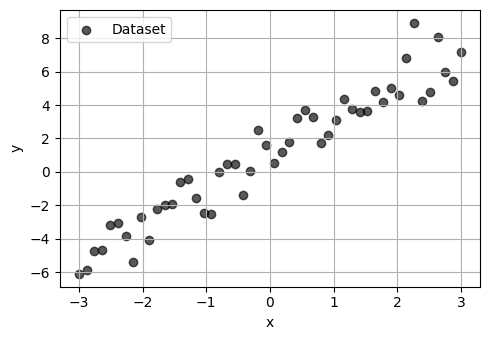

In [2]:

# ============================================================
# 1. Generate toy dataset
# ============================================================
torch.manual_seed(0)

N = 50
x = torch.linspace(-3, 3, N).reshape(-1, 1)

true_w = torch.tensor([[2.0]])
true_b = torch.tensor([[1.0]])

noise = 1.0 * torch.randn(N, 1)
y = x @ true_w + true_b + noise





# ============================================================
# Plot dataset only
# ============================================================
plt.figure(figsize=(5, 3.5))

plt.scatter(
    x.numpy(),
    y.numpy(),
    color="black",
    alpha=0.65,
    label="Dataset"
)

plt.xlabel("x")
plt.ylabel("y")
# plt.title("Toy Dataset")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## **Model and loss.** 

The predictor is

$$
f(x;\theta)=wx+b.
$$

Both training methods minimize

$$
\mathcal L(w,b)
=\frac{1}{2N}\sum_{i=1}^{N}(y_i-wx_i-b)^2
+\frac{\lambda}{2}w^2.
$$

The first term measures the fitting error. The second penalizes a large weight; the bias is not penalized.



## **Closed-form solution.** 

A column of ones represents the bias, giving $X_{\mathrm{aug}}=[x,\mathbf{1}]$ and $\theta=[w,b]^\top$. We solve

$$
\left(X_{\mathrm{aug}}^\top X_{\mathrm{aug}}+N\lambda R\right)\hat\theta
=X_{\mathrm{aug}}^\top y,
$$

where $R=\operatorname{diag}(1,0)$ is named `I` in the code. The factor $N$ comes from averaging the squared errors. `torch.linalg.solve` solves this system without explicitly computing an inverse.

In [3]:

# ============================================================
# 2. Closed-form solution
# ============================================================
lam = 1e-3

# Augmented design matrix: [x, 1]
X_aug = torch.cat([x, torch.ones_like(x)], dim=1)  # shape: (N, 2)

# Regularization matrix
# We regularize w, but not bias b.
I = torch.eye(X_aug.shape[1])
I[-1, -1] = 0.0

# Since the training loss uses mean squared loss,
# the matching closed-form solution uses N * lam.
theta_closed = torch.linalg.solve(
    X_aug.T @ X_aug + N * lam * I,
    X_aug.T @ y
)

w_closed = theta_closed[0:1]   # shape: (1, 1)
b_closed = theta_closed[1:2]   # shape: (1, 1)




## **Gradient descent.** 

Starting from random parameters, we repeatedly update

$$
\theta\leftarrow\theta-\eta\nabla\mathcal L(\theta).
$$

`loss.backward()` computes the gradients. We update the parameters inside `torch.no_grad()` without tracking the update for automatic differentiation. Then, `zero_()` clears the gradients before the next iteration.

In [10]:


# ============================================================
# 3. Gradient descent training
# ============================================================
w = torch.randn(1, 1, requires_grad=True)
b = torch.randn(1, 1, requires_grad=True)

lr = 0.05
num_steps = 100
save_steps = [0, 1, 5, 10, 50, 99]

loss_history = []
snapshots = {}


def compute_loss(w, b):
    y_pred = x @ w + b
    mse_loss = 0.5 * torch.mean((y - y_pred) ** 2)
    reg_loss = 0.5 * lam * torch.sum(w ** 2)
    return mse_loss + reg_loss


for k in range(num_steps):
    # Compute loss
    loss = compute_loss(w, b)

    # Save loss and current parameter
    loss_history.append(loss.item())

    if k in save_steps:
        snapshots[k] = (w.detach().clone(), b.detach().clone())

    # Backpropagation
    loss.backward()

    if k in save_steps:
        print(f"Step {k:3d}: loss = {loss.item():.6f}")

    # Gradient descent update
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

    # Reset gradients
    w.grad.zero_()
    b.grad.zero_()


w_gd = w.detach()
b_gd = b.detach()

print('')
print("Closed-form solution")
print(f"w = {w_closed.item():.4f}, b = {b_closed.item():.4f}")

print("\nGradient descent solution")
print(f"w = {w_gd.item():.4f}, b = {b_gd.item():.4f}")


Step   0: loss = 1.133386
Step   1: loss = 1.007064
Step   5: loss = 0.750964
Step  10: loss = 0.648807
Step  50: loss = 0.568323
Step  99: loss = 0.567189

Closed-form solution
w = 2.0949, b = 1.0488

Gradient descent solution
w = 2.0949, b = 1.0451


## **Visualization.** 

Blue lines show the gradient-descent fits at selected steps; the red line shows the closed-form fit. The right panel shows the corresponding loss values.

Snapshots are recorded before each update: step 0 shows the initial parameters, while the final printed parameters are obtained after 100 updates.

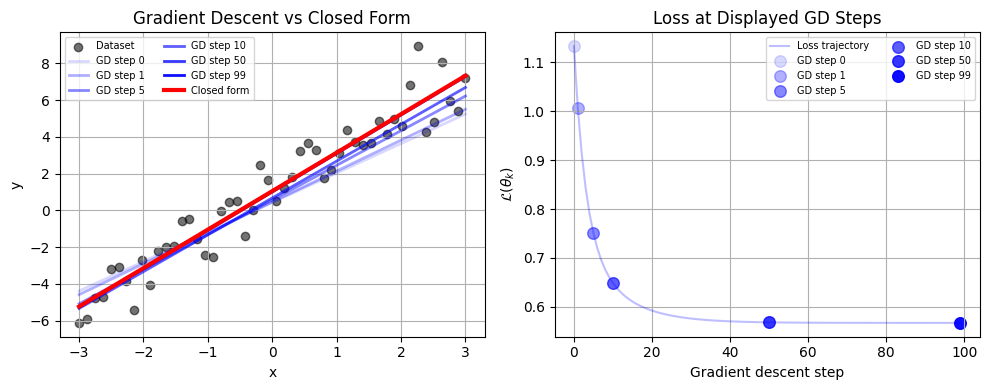

In [11]:

# ============================================================
# 4. Visualization
# ============================================================
x_plot = torch.linspace(-3, 3, 100).reshape(-1, 1)
y_closed = x_plot @ w_closed + b_closed

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

gd_steps = list(snapshots.keys())
alphas = torch.linspace(0.15, 0.95, len(gd_steps))


# ------------------------------------------------------------
# Left: GD trajectory and closed-form solution
# ------------------------------------------------------------
ax = axes[0]

ax.scatter(
    x.numpy(),
    y.numpy(),
    color="black",
    alpha=0.55,
    label="Dataset"
)

for alpha, k in zip(alphas, gd_steps):
    wk, bk = snapshots[k]
    y_gd_step = x_plot @ wk + bk

    ax.plot(
        x_plot.numpy(),
        y_gd_step.numpy(),
        color="blue",
        alpha=float(alpha),
        linewidth=2,
        label=f"GD step {k}"
    )

ax.plot(
    x_plot.numpy(),
    y_closed.numpy(),
    color="red",
    linewidth=3,
    label="Closed form"
)

ax.set_title("Gradient Descent vs Closed Form")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True)
ax.legend(fontsize=7, ncol=2)


# ------------------------------------------------------------
# Right: Loss values corresponding to displayed GD steps
# ------------------------------------------------------------
ax = axes[1]

# Full loss trajectory
ax.plot(
    range(num_steps),
    loss_history,
    color="blue",
    alpha=0.25,
    linewidth=1.5,
    label="Loss trajectory"
)

# Loss values corresponding to the GD steps shown in the left panel
for alpha, k in zip(alphas, gd_steps):
    ax.scatter(
        k,
        loss_history[k],
        color="blue",
        alpha=float(alpha),
        s=70,
        label=f"GD step {k}"
    )

ax.set_title("Loss at Displayed GD Steps")
ax.set_xlabel("Gradient descent step")
ax.set_ylabel(r"$\mathcal{L}(\theta_k)$")
ax.grid(True)
ax.legend(fontsize=7, ncol=2)


# ============================================================
# 5. Save and show
# ============================================================
plt.tight_layout()
fig.savefig("gd_vs_closed_form.png", dpi=300, bbox_inches="tight")
plt.show()

## **Question:** 

As the loss decreases, does the gradient-descent line approach the closed-form line?

